In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

import ioumatch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_ROOT = Path("data/prepared/pannuke")


DEVICE: cuda


In [2]:
# --- Cellpose (API v4+) : helpers ---
from cellpose import models as cp_models

_CP = None
def get_cellpose():
    global _CP
    if _CP is None:
        _CP = cp_models.CellposeModel(gpu=torch.cuda.is_available())
    return _CP

def predict_cellpose_instances(img_chw: np.ndarray, diameter=None) -> np.ndarray:
    """img_chw: (3,H,W) float in [0,1] (ou uint8). Retour (H,W) int32 instances."""
    img = np.transpose(img_chw, (1,2,0))  # HWC
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    cp = get_cellpose()
    masks, flows, styles = cp.eval(img, diameter=diameter, do_3D=False)
    return masks.astype(np.int32, copy=False)


In [3]:
def dice_iou_bin(pred_bin: np.ndarray, gt_bin: np.ndarray):
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)


def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    res = ioumatch.evaluate_image(
        pred_inst.astype(np.int32),
        gt_inst.astype(np.int32),
        threshold=iou_thr,
        method="greedy",
        inclusive=False,
        normalize=False,
    )
    TP, FP, FN = int(res["tp"]), int(res["fp"]), int(res["fn"])
    f1 = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    return float(f1), TP, FP, FN, res["iou_matrix"]


In [4]:
from src.pannuke_dataset import PannukePreparedDataset

def get_raw_dataset(split: str):
    return PannukePreparedDataset(
        root=DATA_ROOT,
        split=split,
        transform=None,
        return_image_name=True,
    )

ds_val = get_raw_dataset("val")
print("VAL size:", len(ds_val))


VAL size: 2465


In [5]:
# Évaluation U-Net (avec post-processing watershed)
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)

    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)


In [6]:
from pathlib import Path

MODELS_DIR = Path("models")
if not MODELS_DIR.exists():
    MODELS_DIR.resolve().mkdir()
from models.lit_unet_pannuke import UNetLightning  # ton LightningModule

CKPT_UNET_BEST = "models/checkpoints/unet_pannuke_lit_best.ckpt"

unet = UNetLightning.load_from_checkpoint(CKPT_UNET_BEST).to(DEVICE).eval()
print("U-Net loaded")


U-Net loaded


In [7]:
# Eval U-Net sur un split (val/test)
def eval_unet_on_split(split="val", max_images=None, thr=0.5, min_size=20, h=1.5):
    ds = get_raw_dataset(split)
    rows = []

    n = len(ds) if max_images is None else min(len(ds), max_images)

    for i in tqdm(range(n), desc=f"U-Net eval {split}"):
        img_t, gt_inst_t, _, name = ds[i]
        img_b = img_t.unsqueeze(0).to(DEVICE)

        gt_inst = gt_inst_t.numpy().astype(np.int32)
        gt_bin = (gt_inst > 0).astype(np.uint8)

        with torch.no_grad():
            logits = unet(img_b)  # (1,1,H,W)
            prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

        pred_bin = (prob > thr).astype(np.uint8)
        dice, iou = dice_iou_bin(pred_bin, gt_bin)

        pred_inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
        f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=0.5)

        rows.append({
            "image": name,
            "dice": dice,
            "iou": iou,
            "f1_inst": f1,
            "TP": TP, "FP": FP, "FN": FN,
        })

    df = pd.DataFrame(rows)
    return df

df_unet_val = eval_unet_on_split("val", max_images=50)
df_unet_val.describe()


U-Net eval val: 100%|██████████| 50/50 [00:06<00:00,  7.94it/s]


,dice,iou,f1_inst,TP,FP,FN
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000
mean,0.827819,0.710336,0.616958,10.580000,10.020000,3.56000
std,0.059361,0.083063,0.166113,5.413852,6.810826,2.40034
min,0.665075,0.498212,0.205128,2.000000,0.000000,0.00000
25%,0.811538,0.682848,0.513187,7.250000,5.000000,2.00000
50%,0.842906,0.728475,0.655914,9.500000,9.000000,3.00000
75%,0.869522,0.769163,0.735714,12.000000,13.750000,5.00000
max,0.927646,0.865056,0.900000,29.000000,32.000000,10.00000


In [8]:
from models.lit_stardist_pannuke import StarDistLightning
from models.stardist import stardist_decode

CKPT_SD_BEST = "models/checkpoints/stardist_pannuke_best.ckpt"

sd = StarDistLightning.load_from_checkpoint(CKPT_SD_BEST).to(DEVICE).eval()
print("StarDist loaded")


StarDist loaded


In [9]:
def eval_stardist_on_split(
    split="val",
    max_images=None,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=256,
    vote_thr=0.5,
    use_local_maxima=False,
    local_max_footprint=9,
    iou_thr_inst=0.5,
):
    ds = get_raw_dataset(split)
    rows = []

    n = len(ds) if max_images is None else min(len(ds), max_images)

    for i in tqdm(range(n), desc=f"StarDist eval {split}"):
        img_t, gt_inst_t, _, name = ds[i]
        img_b = img_t.unsqueeze(0).to(DEVICE)

        gt_inst = gt_inst_t.numpy().astype(np.int32)
        gt_bin = (gt_inst > 0).astype(np.uint8)

        with torch.no_grad():
            prob_logits, dist_pos, class_logits = sd(img_b)  # <- tuple

        # prob: (H,W) in [0,1]
        prob = torch.sigmoid(prob_logits)[0, 0].detach().cpu().numpy().astype(np.float32)

        # dist: (R,H,W) in pixels [0..CLAMP_DIST] if your model is configured like that
        dist = dist_pos[0].detach().cpu().numpy().astype(np.float32)

        # class probabilities (C,H,W) if your decode expects it
        class_prob = torch.softmax(class_logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)

        # decode (match your training sanity callback signature)
        pred_inst, _pred_cls = stardist_decode(
            prob_map=prob,
            dist_map=dist,
            class_prob=class_prob,
            prob_thr=float(prob_thr),
            nms_iou_thr=float(nms_iou_thr),
            use_local_maxima=bool(use_local_maxima),
            local_max_footprint=int(local_max_footprint),
            max_candidates=int(max_candidates),
            min_area=int(min_area),
            vote_thr=float(vote_thr),
        )

        pred_bin = (pred_inst > 0).astype(np.uint8)

        dice, iou = dice_iou_bin(pred_bin, gt_bin)
        f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=float(iou_thr_inst))

        rows.append(
            {
                "image": name,
                "dice": float(dice),
                "iou": float(iou),
                "f1_inst": float(f1),
                "TP": int(TP),
                "FP": int(FP),
                "FN": int(FN),
                "n_pred": int(pred_inst.max()),
                "n_gt": int(gt_inst.max()),
            }
        )

    return pd.DataFrame(rows)


df_sd_val = eval_stardist_on_split("val", max_images=50)
df_sd_val.describe()


StarDist eval val: 100%|██████████| 50/50 [00:18<00:00,  2.67it/s]


,dice,iou,f1_inst,TP,FP,FN,n_pred,n_gt
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.310541,0.187893,0.269960,2.240000,0.600000,11.900000,2.840000,14.140000
std,0.099925,0.070542,0.123589,1.238168,0.880631,6.017831,1.503194,6.673157
min,0.121884,0.064897,0.000000,0.000000,0.000000,3.000000,1.000000,5.000000
25%,0.233169,0.131975,0.183983,1.000000,0.000000,8.000000,2.000000,9.250000
50%,0.315465,0.187273,0.264912,2.000000,0.000000,10.000000,3.000000,13.000000
75%,0.396031,0.246955,0.333333,3.000000,1.000000,13.750000,3.750000,17.000000
max,0.486903,0.321792,0.600000,5.000000,3.000000,28.000000,7.000000,33.000000


In [10]:
# Eval Cellpose sur un split (val/test)
def eval_cellpose_on_split(split="val", max_images=None, diameter=None, iou_thr_inst=0.5):
    ds = get_raw_dataset(split)
    rows = []
    n = len(ds) if max_images is None else min(len(ds), max_images)

    for i in tqdm(range(n), desc=f"Cellpose eval {split}"):
        img_t, gt_inst_t, _, name = ds[i]

        img_chw = img_t.cpu().numpy()
        gt_inst = gt_inst_t.numpy().astype(np.int32)
        gt_bin = (gt_inst > 0).astype(np.uint8)

        pred_inst = predict_cellpose_instances(img_chw, diameter=diameter)
        pred_bin = (pred_inst > 0).astype(np.uint8)

        dice, iou = dice_iou_bin(pred_bin, gt_bin)
        f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=float(iou_thr_inst))

        rows.append({
            "image": name,
            "dice": float(dice),
            "iou": float(iou),
            "f1_inst": float(f1),
            "TP": int(TP),
            "FP": int(FP),
            "FN": int(FN),
            "n_pred": int(pred_inst.max()),
            "n_gt": int(gt_inst.max()),
        })

    return pd.DataFrame(rows)


In [11]:
df_unet_val = eval_unet_on_split("val", max_images=50, thr=0.5, min_size=20, h=1.5)
df_sd_val   = eval_stardist_on_split("val", max_images=50, prob_thr=0.5, nms_iou_thr=0.3, min_area=10, max_candidates=256)
df_cp_val   = eval_cellpose_on_split("val", max_images=50, diameter=None, iou_thr_inst=0.5)

df_unet_val["model"] = "UNet"
df_sd_val["model"]   = "StarDist"
df_cp_val["model"]   = "Cellpose"

df_all = pd.concat([df_unet_val, df_sd_val, df_cp_val], ignore_index=True)

print(df_all.groupby("model")[["dice","iou","f1_inst"]].mean())

out_csv = Path("eval_val_50images.csv")
df_all.to_csv(out_csv, index=False)
print("Saved:", out_csv.resolve())


Cellpose eval val: 100%|██████████| 50/50 [00:30<00:00,  1.63it/s]

              dice       iou   f1_inst
model                                 
Cellpose  0.782695  0.649849  0.724002
StarDist  0.310541  0.187893  0.269960
UNet      0.827819  0.710336  0.616958
Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\eval_val_50images.csv


In [12]:
@torch.no_grad()
def predict_unet_instances(img_chw: np.ndarray, thr=0.5, min_size=20, h=1.5):
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)  # (1,3,H,W)
    logits = unet(x)  # (1,1,H,W)
    prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy().astype(np.float32)
    inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
    return inst, prob


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import ioumatch

# U-Net postprocess
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

# StarDist decode
from models.stardist import stardist_decode

# dataset
from src.pannuke_dataset import PannukePreparedDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

BASE_DIR = Path(".")
DATA_ROOT = BASE_DIR / "data" / "prepared" / "pannuke"
MORPH_CSV = DATA_ROOT / "pannuke_morphology_with_classes.csv"

# checkpoints
UNET_CKPT = BASE_DIR / "models" / "checkpoints" / "unet_pannuke_lit_best.ckpt"
STARDIST_CKPT = BASE_DIR / "models" / "checkpoints" / "stardist_pannuke_best.ckpt"

print("DATA_ROOT:", DATA_ROOT)
print("MORPH_CSV:", MORPH_CSV, MORPH_CSV.exists())


DEVICE: cuda
DATA_ROOT: data\prepared\pannuke
MORPH_CSV: data\prepared\pannuke\pannuke_morphology_with_classes.csv True


In [14]:
from models.lit_unet_pannuke import UNetLightning
from models.lit_stardist_pannuke import StarDistLightning

unet = UNetLightning.load_from_checkpoint(str(UNET_CKPT), map_location=DEVICE).to(DEVICE).eval()
stard = StarDistLightning.load_from_checkpoint(str(STARDIST_CKPT), map_location=DEVICE).to(DEVICE).eval()

print("Loaded:", type(unet), type(stard))


Loaded: <class 'models.lit_unet_pannuke.UNetLightning'> <class 'models.lit_stardist_pannuke.StarDistLightning'>


In [15]:
@torch.inference_mode()
def predict_stardist_instances(
    img_chw: np.ndarray,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=256,
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=3,
):
    """Retourne (pred_inst, prob_map, pred_cls). pred_cls peut être None selon ton decode."""
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)

    # StarDist renvoie un tuple: (prob_logits, dist_pos, class_logits)
    prob_logits, dist_pos, class_logits = stard(x)

    prob_map = torch.sigmoid(prob_logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    dist_map = dist_pos[0].detach().cpu().numpy().astype(np.float32)

    # classes (si ton modèle les fournit)
    class_prob = torch.softmax(class_logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)

    dec = stardist_decode(
        prob_map=prob_map,
        dist_map=dist_map,
        class_prob=class_prob,
        prob_thr=float(prob_thr),
        nms_iou_thr=float(nms_iou_thr),
        min_area=int(min_area),
        max_candidates=int(max_candidates),
        vote_thr=float(vote_thr),
        use_local_maxima=bool(use_local_maxima),
        local_max_footprint=int(local_max_footprint),
    )

    if isinstance(dec, tuple):
        pred_inst = dec[0]
        pred_cls = dec[1] if len(dec) > 1 else None
    else:
        pred_inst = dec
        pred_cls = None

    pred_inst = pred_inst.astype(np.int32, copy=False)
    return pred_inst, prob_map, pred_cls


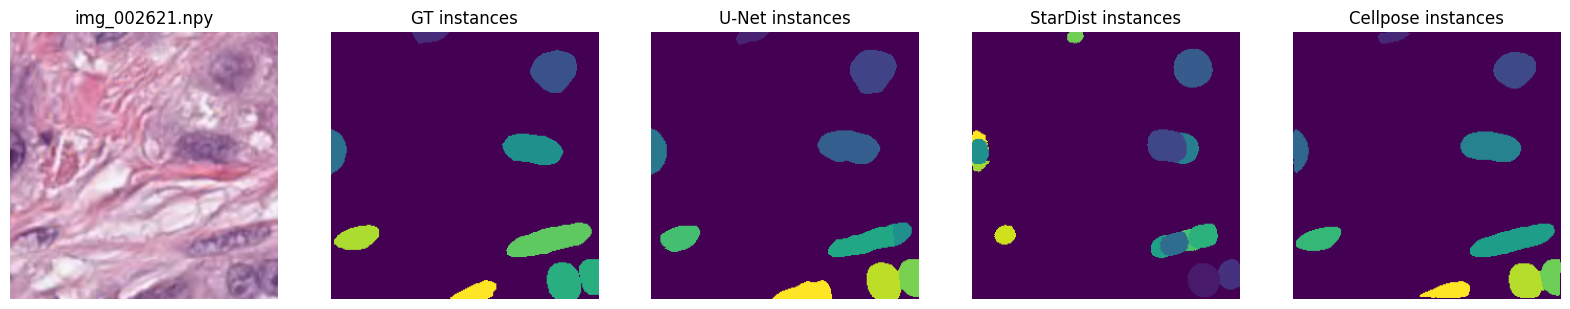

In [16]:
def show_case(idx=0, split="val", unet_thr=0.5,
              prob_thr=0.5, nms_iou_thr=0.3, min_area=10,
              max_candidates=5000, vote_thr=0.5,
              use_local_maxima=False, local_max_footprint=9,
              cp_diameter=None):
    ds = get_raw_dataset(split)
    img_t, gt_inst_t, _, name = ds[idx]

    img_chw = img_t.cpu().numpy()
    img = np.transpose(img_chw, (1, 2, 0))  # (H,W,3)
    gt = gt_inst_t.cpu().numpy().astype(np.int32)

    # U-Net pred
    pu, _ = predict_unet_instances(img_chw, thr=unet_thr)

    # StarDist pred
    ps, _, _ = predict_stardist_instances(
        img_chw,
        prob_thr=prob_thr,
        nms_iou_thr=nms_iou_thr,
        min_area=min_area,
        max_candidates=max_candidates,
        vote_thr=vote_thr,
        use_local_maxima=use_local_maxima,
        local_max_footprint=local_max_footprint,
    )

    # Cellpose pred (API v4+)
    pc = predict_cellpose_instances(img_chw, diameter=cp_diameter)

    fig, axs = plt.subplots(1, 5, figsize=(20, 4))
    axs[0].imshow(img); axs[0].set_title(name); axs[0].axis("off")
    axs[1].imshow(gt); axs[1].set_title("GT instances"); axs[1].axis("off")
    axs[2].imshow(pu); axs[2].set_title("U-Net instances"); axs[2].axis("off")
    axs[3].imshow(ps); axs[3].set_title("StarDist instances"); axs[3].axis("off")
    axs[4].imshow(pc); axs[4].set_title("Cellpose instances"); axs[4].axis("off")
    plt.show()

show_case(idx=0, split="val")


In [17]:
df_unet_test = eval_unet_on_split("test", max_images=None)



U-Net eval test: 100%|██████████| 2656/2656 [11:37<00:00,  3.81it/s]  


In [18]:
df_cp_test   = eval_cellpose_on_split("test", max_images=None)

Cellpose eval test: 100%|██████████| 2656/2656 [41:54<00:00,  1.06it/s]


In [19]:
df_sd_test   = eval_stardist_on_split("test", max_images=None)


StarDist eval test: 100%|██████████| 2656/2656 [17:39<00:00,  2.51it/s]


In [20]:
df_unet_test["model"] = "UNet"
df_sd_test["model"] = "StarDist"
df_cp_val["model"] = "Cellpose"

df_test = pd.concat([df_unet_test, df_sd_test, df_cp_test], ignore_index=True)
print(df_test.groupby("model")[["dice","iou","f1_inst"]].mean())

df_test.to_csv("eval_test_all.csv", index=False)

              dice       iou   f1_inst
model                                 
StarDist  0.314599  0.198361  0.260592
UNet      0.815737  0.708400  0.579319


In [21]:
assert MORPH_CSV.exists(), " CSV morpho manque. Re-run compute_morphology_pannuke.py"
morph = pd.read_csv(MORPH_CSV)

print(morph.shape)
print(morph.columns.tolist())
print("class_id==0 ratio:", (morph["class_id"] == 0).mean())
print(morph["morph_class"].value_counts())
print(morph["size_bin_q"].value_counts())


(162995, 14)
['split', 'image', 'instance_id', 'class_id', 'area', 'perimeter', 'eccentricity', 'solidity', 'circularity', 'bbox_aspect', 'centroid_row', 'centroid_col', 'morph_class', 'size_bin_q']
class_id==0 ratio: 0.0
morph_class
elongated    68942
other        45189
round        37462
irregular    11402
Name: count, dtype: int64
size_bin_q
small     54542
large     54294
medium    54159
Name: count, dtype: int64


In [22]:
def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    """
    prob: (H,W) float32 in [0,1]
    returns inst_map (H,W) int32
    """
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)

    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)


In [23]:
def _iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum(dtype=np.float32)
    union = np.logical_or(a, b).sum(dtype=np.float32)
    return float(inter / union) if union > 0 else 0.0


def match_gt_instances(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    """
    Matching "GT-centric":
    pour chaque instance GT, on calcule iou_max = max IoU contre toutes les instances prédites.
    TP = iou_max >= iou_thr

    Avantages:
      - marche même si les ids ne sont pas contigus
      - marche même si pred ids non contigus
      - pas de dépendance à la convention interne de ioumatch
    """
    gt_ids = np.unique(gt_inst)
    gt_ids = gt_ids[gt_ids > 0]
    if gt_ids.size == 0:
        return pd.DataFrame(columns=["instance_id", "iou_max", "TP"])

    pred_ids = np.unique(pred_inst)
    pred_ids = pred_ids[pred_ids > 0]
    if pred_ids.size == 0:
        return pd.DataFrame({
            "instance_id": gt_ids.astype(int),
            "iou_max": np.zeros(gt_ids.size, dtype=float),
            "TP": np.zeros(gt_ids.size, dtype=int),
        })

    # Pré-calc des masques prédits (pour éviter de refaire pred_inst==id 500 fois)
    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}

    iou_max_list = []
    for gid in gt_ids:
        gt_mask = (gt_inst == gid)
        best = 0.0
        for pid in pred_ids:
            iou = _iou_binary(gt_mask, pred_masks[pid])
            if iou > best:
                best = iou
        iou_max_list.append(best)

    iou_max = np.array(iou_max_list, dtype=float)
    TP = (iou_max >= iou_thr).astype(int)

    return pd.DataFrame({
        "instance_id": gt_ids.astype(int),
        "iou_max": iou_max,
        "TP": TP
    })


In [24]:
ds_val = PannukePreparedDataset(root=DATA_ROOT, split="val", transform=None, return_image_name=True)
ds_test = PannukePreparedDataset(root=DATA_ROOT, split="test", transform=None, return_image_name=True)

def get_sample(ds, idx):
    img_t, gt_inst_t, types_t, name = ds[idx]
    img = img_t.numpy()  # (3,H,W)
    gt_inst = gt_inst_t.numpy().astype(np.int32)  # (H,W)
    return img, gt_inst, name


In [25]:
from tqdm import tqdm
import pandas as pd

def build_match_df(
    ds,
    model_name: str,
    iou_thr=0.5,
    max_images=None,
    skip_empty_gt=True,
    desc=None,
    **kwargs
):
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    n_empty_gt = 0
    n_empty_pred = 0

    if desc is None:
        desc = f"match {model_name}"

    for i in tqdm(range(n), desc=desc):
        img, gt_inst, name = get_sample(ds, i)

        # gt_inst attendu: np.int32 (H,W) avec 0=bg
        if skip_empty_gt and (gt_inst.max() == 0):
            n_empty_gt += 1
            continue

        if model_name == "unet":
            pred_inst, _ = predict_unet_instances(img, **kwargs)
        elif model_name == "stardist":
            pred_inst, _, _ = predict_stardist_instances(img, **kwargs)
        elif model_name == "cellpose":
            pred_inst = predict_cellpose_instances(img, **kwargs)
        else:
            raise ValueError(f"Unknown model_name={model_name}")

        if pred_inst.max() == 0:
            n_empty_pred += 1

        # matching GT->pred : on récupère iou_max par instance GT + TP flag
        m = match_gt_instances(pred_inst, gt_inst, iou_thr=float(iou_thr))
        m["image"] = name
        rows.append(m)

    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    out.attrs["n_empty_gt"] = n_empty_gt
    out.attrs["n_empty_pred"] = n_empty_pred
    return out


In [26]:
unet_val = build_match_df(
    ds_val, "unet", iou_thr=0.5,
    thr=0.5, min_size=20, h=1.5
).rename(columns={"iou_max":"unet_iou", "TP":"unet_TP"})




match unet: 100%|██████████| 2465/2465 [11:26<00:00,  3.59it/s] 


In [27]:
stard_val = build_match_df(
    ds_val, "stardist", iou_thr=0.5,
    prob_thr=0.5, nms_iou_thr=0.3,
    min_area=10,
    max_candidates=256,
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=3,
).rename(columns={"iou_max":"stardist_iou", "TP":"stardist_TP"})

cellpose_val = build_match_df(
    ds_val, "cellpose", iou_thr=0.5,
    diameter=None,   # baseline sans tuning
).rename(columns={"iou_max":"cellpose_iou", "TP":"cellpose_TP"})

print(unet_val.shape, stard_val.shape, cellpose_val.shape)
unet_val.head()


match cellpose: 100%|██████████| 2465/2465 [40:14<00:00,  1.02it/s]

(51719, 4) (51719, 4) (51719, 4)


,instance_id,unet_iou,unet_TP,image
0,1,0.863354,1,img_002621.npy
1,2,0.895777,1,img_002621.npy
2,3,0.936508,1,img_002621.npy
3,4,0.787706,1,img_002621.npy
4,5,0.618217,1,img_002621.npy


In [28]:
df = morph[morph["split"]=="val"].copy()

df = df.merge(unet_val, on=["image","instance_id"], how="left")
df = df.merge(stard_val, on=["image","instance_id"], how="left")
df = df.merge(cellpose_val, on=["image","instance_id"], how="left")

for c in ["unet_TP","stardist_TP","cellpose_TP"]:
    df[c] = df[c].fillna(0).astype(int)

for c in ["unet_iou","stardist_iou","cellpose_iou"]:
    df[c] = df[c].fillna(0.0)

print(df.shape)
df.head()


(51719, 20)


,split,image,instance_id,class_id,area,perimeter,eccentricity,solidity,circularity,bbox_aspect,centroid_row,centroid_col,morph_class,size_bin_q,unet_iou,unet_TP,stardist_iou,stardist_TP,cellpose_iou,cellpose_TP
0,val,img_002621.npy,1,1,315.0,82.627417,0.940032,0.954545,0.579792,3.000000,4.368254,93.298413,elongated,medium,0.863354,1,0.408955,0,0.761006,1
1,val,img_002621.npy,2,1,1358.0,136.953319,0.450561,0.972083,0.909839,1.097561,37.403535,212.744477,round,large,0.895777,1,0.725829,1,0.795287,1
2,val,img_002621.npy,3,1,473.0,99.112698,0.925129,0.967280,0.605079,0.348837,114.291755,5.704017,elongated,medium,0.936508,1,0.589537,1,0.934021,1
3,val,img_002621.npy,4,1,1337.0,148.225397,0.876078,0.960489,0.764709,1.966667,112.383695,192.269260,elongated,large,0.787706,1,0.629959,1,0.774769,1
4,val,img_002621.npy,5,1,1535.0,195.396970,0.759210,0.898186,0.505222,1.315789,237.001954,231.140065,irregular,large,0.618217,1,0.524430,1,0.579427,1


In [29]:
def summarize_bias(df, group_col):
    g = df.groupby(group_col).agg(
        n=("instance_id","size"),
        unet_recall=("unet_TP","mean"),
        stard_recall=("stardist_TP","mean"),
        cellpose_recall=("cellpose_TP","mean"),
        unet_iou=("unet_iou","mean"),
        stard_iou=("stardist_iou","mean"),
        cellpose_iou=("cellpose_iou","mean"),
    ).reset_index()
    return g.sort_values("n", ascending=False)


In [63]:
img_stats = df.groupby("image").agg(
    n_inst=("instance_id","count"),
    unet_recall=("unet_TP","mean"),
    stard_recall=("stardist_TP","mean"),
    cellpose_recall=("cellpose_TP","mean"),
    mean_area=("area","mean"),
    frac_irregular=("morph_class", lambda s: (s=="irregular").mean()),
    frac_elongated=("morph_class", lambda s: (s=="elongated").mean()),
)

# Score difficulté: dense + faible recall
img_stats["difficulty_unet"] = img_stats["n_inst"] * (1.0 - img_stats["unet_recall"])
img_stats["difficulty_stard"] = img_stats["n_inst"] * (1.0 - img_stats["stard_recall"])
img_stats["difficulty_cellpose"] = img_stats["n_inst"] * (1.0 - img_stats["cellpose_recall"])

img_stats = img_stats.sort_values("difficulty_unet", ascending=False)
img_stats.head()


,n_inst,unet_recall,stard_recall,cellpose_recall,mean_area,frac_irregular,frac_elongated,difficulty_unet,difficulty_stard,difficulty_cellpose
image,,,,,,,,,,
img_003553.npy,238,0.394958,0.226891,0.567227,91.579832,0.096639,0.243697,144.0,184.0,103.0
img_004822.npy,79,0.430380,0.468354,0.683544,161.151899,0.063291,0.430380,45.0,42.0,25.0
img_003552.npy,100,0.550000,0.370000,0.670000,158.060000,0.070000,0.330000,45.0,63.0,33.0
img_005050.npy,120,0.658333,0.450000,0.575000,200.200000,0.050000,0.283333,41.0,66.0,51.0
img_003465.npy,122,0.680328,0.426230,0.737705,146.549180,0.098361,0.147541,39.0,70.0,32.0


In [31]:
unet_test = (build_match_df(ds_test, "unet", iou_thr=0.5, thr=0.5, min_size=20, h=1.5)
             .rename(columns={"iou_max":"unet_iou","TP":"unet_TP"}))
stard_test = (build_match_df(ds_test, "stardist", iou_thr=0.5, prob_thr=0.5, nms_iou_thr=0.3, min_area=10, max_candidates=3000, vote_thr=0.5)
              .rename(columns={"iou_max":"stardist_iou","TP":"stardist_TP"}))
cellpose_test = (build_match_df(ds_test, "cellpose", iou_thr=0.5, diameter=None)
                 .rename(columns={"iou_max":"cellpose_iou","TP":"cellpose_TP"}))

df_test = morph[morph["split"]=="test"].copy()
df_test = df_test.merge(unet_test, on=["image","instance_id"], how="left")
df_test = df_test.merge(stard_test, on=["image","instance_id"], how="left")
df_test = df_test.merge(cellpose_test, on=["image","instance_id"], how="left")

for c in ["unet_TP","stardist_TP","cellpose_TP"]:
    df_test[c] = df_test[c].fillna(0).astype(int)
for c in ["unet_iou","stardist_iou","cellpose_iou"]:
    df_test[c] = df_test[c].fillna(0.0)

display(summarize_bias(df_test, "morph_class"))
display(summarize_bias(df_test, "size_bin_q"))


match cellpose: 100%|██████████| 2656/2656 [45:09<00:00,  1.02s/it]


,morph_class,n,unet_recall,stard_recall,cellpose_recall,unet_iou,stard_iou,cellpose_iou
0,elongated,24001,0.663597,0.588809,0.599350,0.592012,0.510458,0.497768
2,other,15737,0.801296,0.890703,0.793163,0.704630,0.695420,0.653926
3,round,12983,0.874143,0.936763,0.858353,0.756320,0.761291,0.706318
1,irregular,4108,0.381938,0.175268,0.259981,0.436919,0.363054,0.364661


,size_bin_q,n,unet_recall,stard_recall,cellpose_recall,unet_iou,stard_iou,cellpose_iou
2,small,19029,0.612276,0.600084,0.491250,0.538769,0.519082,0.397105
0,large,18940,0.766631,0.725660,0.754277,0.698888,0.632414,0.670875
1,medium,18860,0.810392,0.841357,0.818929,0.711698,0.674182,0.670363


In [ ]:
# stard_test = (build_match_df(ds_test, "stardist", iou_thr=0.5, prob_thr=0.5, nms_iou_thr=0.3, min_area=10, max_candidates=256)
#               .rename(columns={"iou_max":"stardist_iou","TP":"stardist_TP"}))


In [ ]:
# stard_test = (build_match_df(ds_test, "stardist", iou_thr=0.5, prob_thr=0.5, nms_iou_thr=0.3, min_area=10, max_candidates=256)
#               .rename(columns={"iou_max":"stardist_iou","TP":"stardist_TP"}))


In [50]:
df_test = morph[morph["split"]=="test"].copy()
df_test = df_test.merge(unet_test, on=["image","instance_id"], how="left")
df_test = df_test.merge(stard_test, on=["image","instance_id"], how="left")
df_test = df_test.merge(cellpose_test, on=["image","instance_id"], how="left")

for c in ["unet_TP","stardist_TP","cellpose_TP"]:
    df_test[c] = df_test[c].fillna(0).astype(int)
for c in ["unet_iou","stardist_iou","cellpose_iou"]:
    df_test[c] = df_test[c].fillna(0.0)


[TEST] Instance recall@0.5  U-Net=0.729  StarDist=0.722
[TEST] Mean IoU_max        U-Net=0.650  StarDist=0.608


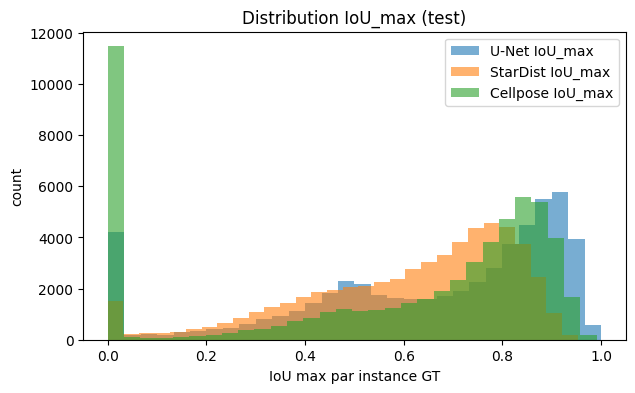

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def quick_global_overview(df):
    # perf globale (instance-level recall @ IoU>=0.5, vu ton TP)
    unet_rec = df["unet_TP"].mean()
    stard_rec = df["stardist_TP"].mean()

    print(f"[TEST] Instance recall@0.5  U-Net={unet_rec:.3f}  StarDist={stard_rec:.3f}")
    print(f"[TEST] Mean IoU_max        U-Net={df['unet_iou'].mean():.3f}  StarDist={df['stardist_iou'].mean():.3f}")

    # histogram IoU
    plt.figure(figsize=(7,4))
    plt.hist(df["unet_iou"].values, bins=30, alpha=0.6, label="U-Net IoU_max")
    plt.hist(df["stardist_iou"].values, bins=30, alpha=0.6, label="StarDist IoU_max")
    plt.hist(df["cellpose_iou"].values, bins=30, alpha=0.6, label="Cellpose IoU_max")
    plt.xlabel("IoU max par instance GT")
    plt.ylabel("count")
    plt.title("Distribution IoU_max (test)")
    plt.legend()
    plt.show()

quick_global_overview(df_test)


In [41]:
df_test.head()

,split,image,instance_id,class_id,area,perimeter,eccentricity,solidity,circularity,bbox_aspect,centroid_row,centroid_col,morph_class,size_bin_q,unet_iou,unet_TP,stardist_iou,stardist_TP
0,test,img_005086.npy,1,1,1840.0,158.124892,0.522690,0.980810,0.924756,1.159091,24.910870,75.246739,round,large,0.779200,1,0.543478,1
1,test,img_005086.npy,2,1,3338.0,216.894444,0.557597,0.979173,0.891660,1.078125,36.464350,183.814560,round,large,0.900207,1,0.583883,1
2,test,img_005086.npy,3,1,1340.0,149.539105,0.830732,0.971014,0.753018,0.703704,69.561940,239.358209,elongated,large,0.243867,0,0.673677,1
3,test,img_005086.npy,4,1,931.0,113.941125,0.383150,0.971816,0.901153,0.941176,71.410311,15.611171,round,large,0.476370,0,0.721562,1
4,test,img_005086.npy,5,1,737.0,103.840620,0.613436,0.949742,0.858900,1.000000,70.052917,54.214383,round,large,0.281987,0,0.366963,0


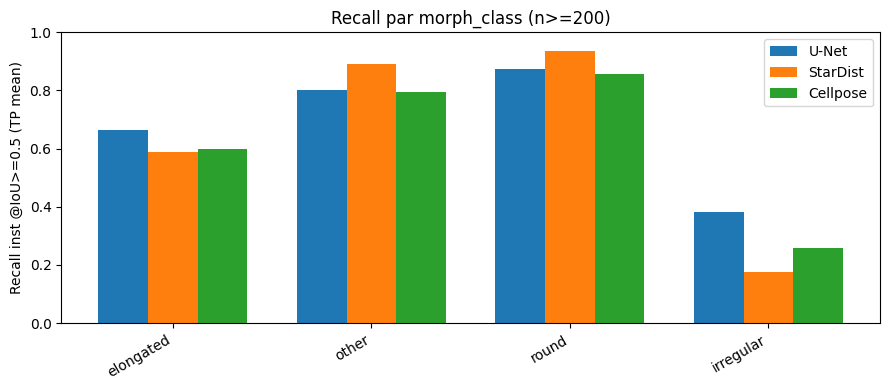

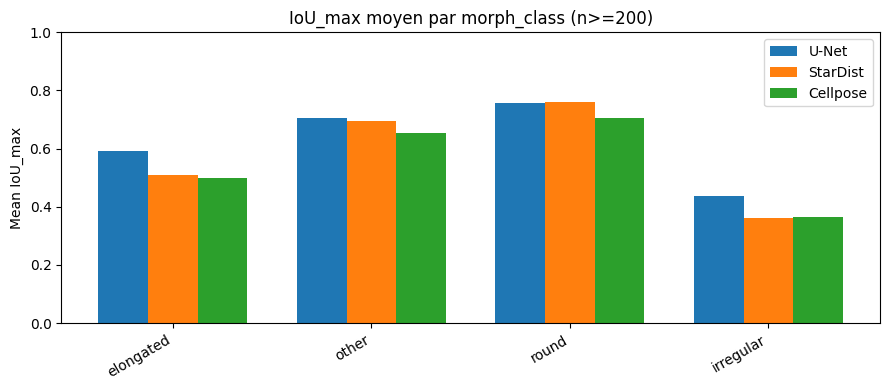

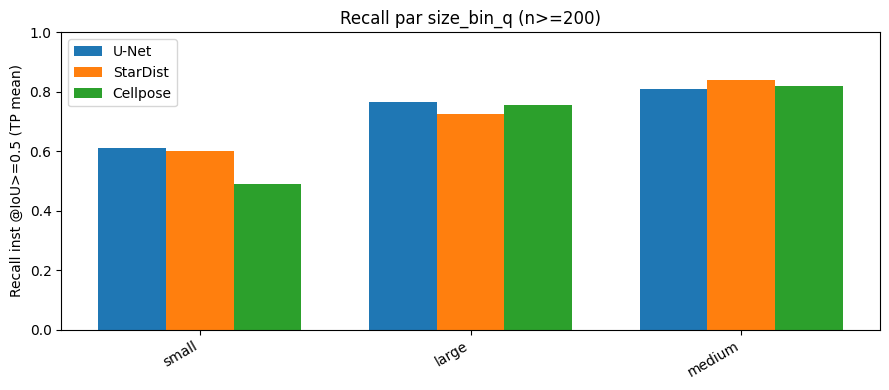

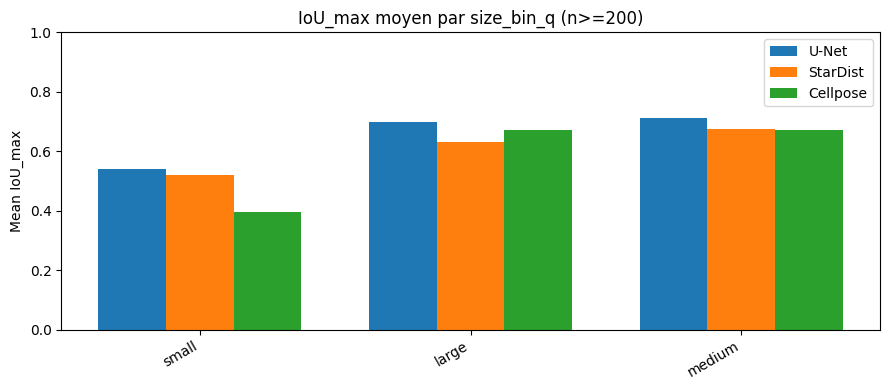

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def plot_group_bias(df, group_col, min_count=50, require_cellpose=False):
    # Vérifs colonnes
    needed_base = ["instance_id", group_col, "unet_TP", "stardist_TP", "unet_iou", "stardist_iou"]
    missing = [c for c in needed_base if c not in df.columns]
    if missing:
        raise KeyError(f"Colonnes manquantes dans df: {missing}")

    has_cp = ("cellpose_TP" in df.columns) and ("cellpose_iou" in df.columns)
    if require_cellpose and not has_cp:
        raise KeyError("cellpose_TP / cellpose_iou absents")

    agg_dict = dict(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stard_rec=("stardist_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stard_iou=("stardist_iou", "mean"),
    )
    if has_cp:
        agg_dict.update(
            cellpose_rec=("cellpose_TP", "mean"),
            cellpose_iou=("cellpose_iou", "mean"),
        )

    g = df.groupby(group_col).agg(**agg_dict).reset_index()
    g = g[g["n"] >= min_count].sort_values("n", ascending=False)

    # positions
    x = np.arange(len(g))

    # ---------- Recall ----------
    plt.figure(figsize=(9, 4))
    if has_cp:
        # 3 barres
        plt.bar(x - 0.25, g["unet_rec"], width=0.25, label="U-Net")
        plt.bar(x,         g["stard_rec"], width=0.25, label="StarDist")
        plt.bar(x + 0.25, g["cellpose_rec"], width=0.25, label="Cellpose")
    else:
        # 2 barres (fallback)
        plt.bar(x - 0.2, g["unet_rec"], width=0.4, label="U-Net")
        plt.bar(x + 0.2, g["stard_rec"], width=0.4, label="StarDist")

    plt.xticks(x, g[group_col].astype(str), rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Recall inst @IoU>=0.5 (TP mean)")
    plt.title(f"Recall par {group_col} (n>={min_count})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- IoU ----------
    plt.figure(figsize=(9, 4))
    if has_cp:
        plt.bar(x - 0.25, g["unet_iou"], width=0.25, label="U-Net")
        plt.bar(x,         g["stard_iou"], width=0.25, label="StarDist")
        plt.bar(x + 0.25, g["cellpose_iou"], width=0.25, label="Cellpose")
    else:
        plt.bar(x - 0.2, g["unet_iou"], width=0.4, label="U-Net")
        plt.bar(x + 0.2, g["stard_iou"], width=0.4, label="StarDist")

    plt.xticks(x, g[group_col].astype(str), rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Mean IoU_max")
    plt.title(f"IoU_max moyen par {group_col} (n>={min_count})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return g



g_morph = plot_group_bias(df_test, "morph_class", min_count=200, require_cellpose=True)
g_size  = plot_group_bias(df_test, "size_bin_q",  min_count=200, require_cellpose=True)



C:\Users\yehadji\AppData\Local\Temp\ipykernel_106160\1544978902.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("area_bin").agg(


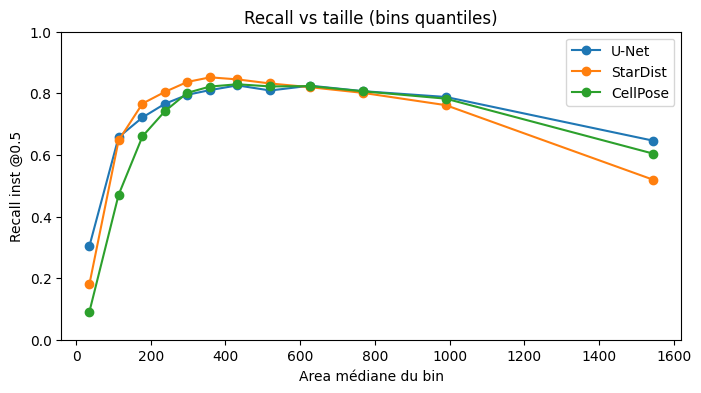

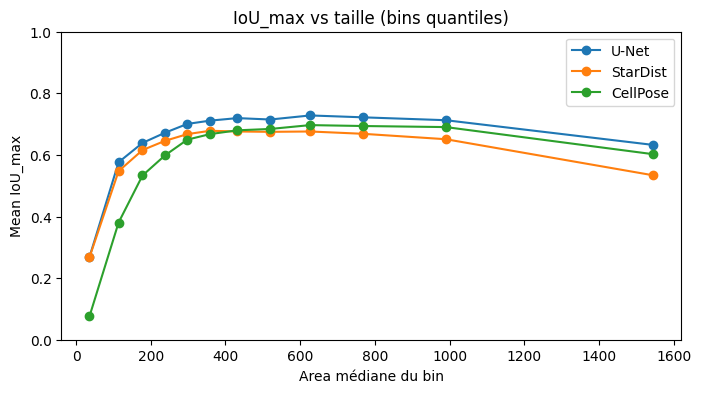

In [57]:
def plot_perf_vs_area(df, q=10):
    tmp = df.copy()
    tmp["area_bin"] = pd.qcut(tmp["area"], q=q, duplicates="drop")

    g = tmp.groupby("area_bin").agg(
        n=("instance_id","size"),
        unet_rec=("unet_TP","mean"),
        stard_rec=("stardist_TP","mean"),
        cellpose_rec=("cellpose_TP","mean"),
        unet_iou=("unet_iou","mean"),
        stard_iou=("stardist_iou","mean"),
        cellpose_iou=("cellpose_iou","mean"),
        area_med=("area","median"),
    ).reset_index().sort_values("area_med")

    plt.figure(figsize=(8,4))
    plt.plot(g["area_med"], g["unet_rec"], marker="o", label="U-Net")
    plt.plot(g["area_med"], g["stard_rec"], marker="o", label="StarDist")
    plt.plot(g["area_med"], g["cellpose_rec"], marker="o", label="CellPose")
    plt.xlabel("Area médiane du bin")
    plt.ylabel("Recall inst @0.5")
    plt.ylim(0,1)
    plt.title("Recall vs taille (bins quantiles)")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(g["area_med"], g["unet_iou"], marker="o", label="U-Net")
    plt.plot(g["area_med"], g["stard_iou"], marker="o", label="StarDist")
    plt.plot(g["area_med"], g["cellpose_iou"], marker="o", label="CellPose")
    plt.xlabel("Area médiane du bin")
    plt.ylabel("Mean IoU_max")
    plt.ylim(0,1)
    plt.title("IoU_max vs taille (bins quantiles)")
    plt.legend()
    plt.show()

    return g


# df_test
g_area = plot_perf_vs_area(df_test, q=12)


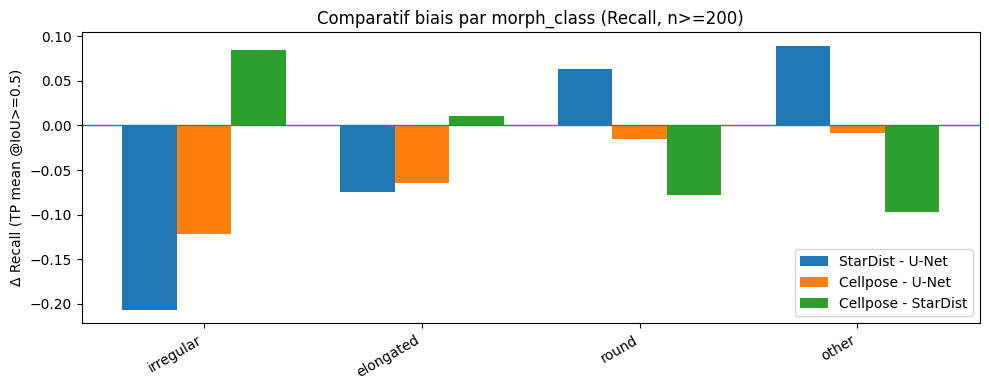

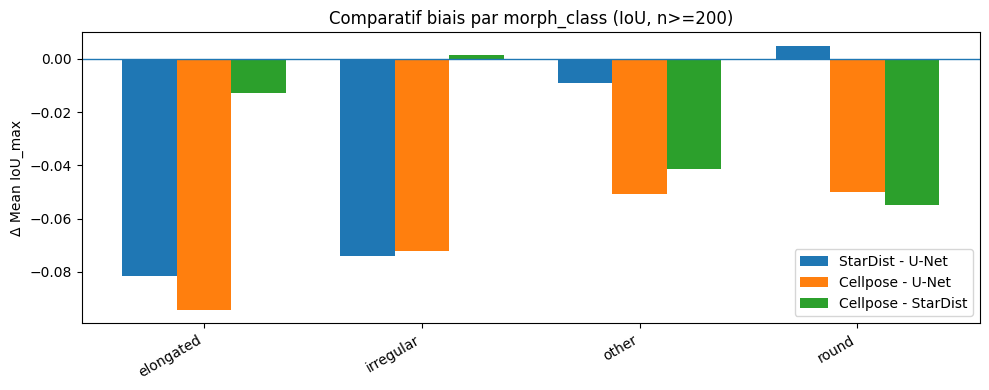

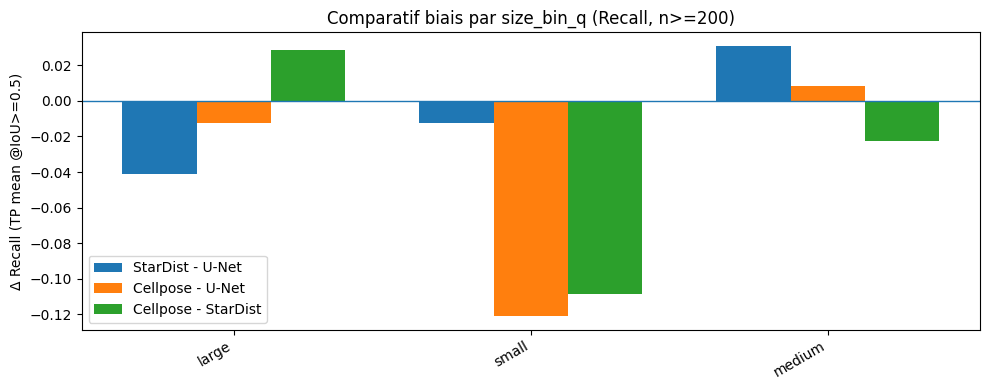

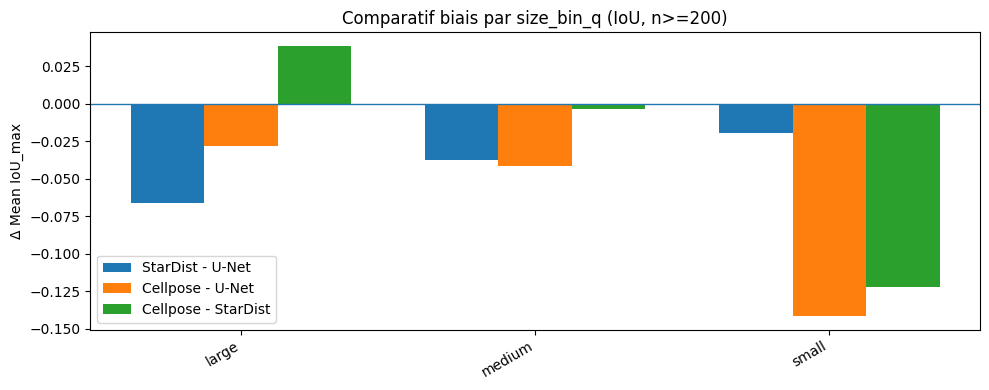

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta(df, group_col, min_count=50, pairs=None, metric="recall"):
    """
    metric: "recall" ou "iou"
    pairs: liste de tuples (A, B, label) signifiant Δ = A - B
           A/B in {"unet", "stardist", "cellpose"}
    """
    # colonnes nécessaires
    needed = ["instance_id", group_col, "unet_TP", "stardist_TP", "unet_iou", "stardist_iou"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Colonnes manquantes dans df: {missing}")

    has_cp = ("cellpose_TP" in df.columns) and ("cellpose_iou" in df.columns)

    if pairs is None:
        # par défaut: toutes les comparaisons utiles
        pairs = [
            ("stardist", "unet", "StarDist - U-Net"),
        ]
        if has_cp:
            pairs += [
                ("cellpose", "unet", "Cellpose - U-Net"),
                ("cellpose", "stardist", "Cellpose - StarDist"),
            ]

    # agrégation par groupe
    agg = dict(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stard_rec=("stardist_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stard_iou=("stardist_iou", "mean"),
    )
    if has_cp:
        agg.update(
            cellpose_rec=("cellpose_TP", "mean"),
            cellpose_iou=("cellpose_iou", "mean"),
        )

    g = df.groupby(group_col).agg(**agg).reset_index()
    g = g[g["n"] >= min_count].copy()

    # choix métrique
    if metric == "recall":
        key = {"unet": "unet_rec", "stardist": "stard_rec", "cellpose": "cellpose_rec"}
        ylab = "Δ Recall (TP mean @IoU>=0.5)"
        title = f"Comparatif biais par {group_col} (Recall, n>={min_count})"
    elif metric == "iou":
        key = {"unet": "unet_iou", "stardist": "stard_iou", "cellpose": "cellpose_iou"}
        ylab = "Δ Mean IoU_max"
        title = f"Comparatif biais par {group_col} (IoU, n>={min_count})"
    else:
        raise ValueError("metric must be 'recall' or 'iou'")

    # vérifier que les colonnes existent (surtout cellpose)
    for a, b, lbl in pairs:
        if a == "cellpose" or b == "cellpose":
            if not has_cp:
                raise KeyError("cellpose_* absent. Merge Cellpose dans df_test ou enlève les paires cellpose.")

    # calcul deltas
    for a, b, lbl in pairs:
        g[lbl] = g[key[a]] - g[key[b]]

    # tri: par la première paire (comme avant)
    g = g.sort_values(pairs[0][2])

    # plot en barres groupées
    plt.figure(figsize=(10, 4))
    x = np.arange(len(g))
    width = 0.25 if len(pairs) >= 3 else 0.35

    # positions autour de x
    offsets = np.linspace(-(len(pairs)-1)/2, (len(pairs)-1)/2, len(pairs)) * width

    for off, (_, _, lbl) in zip(offsets, pairs):
        plt.bar(x + off, g[lbl], width=width, label=lbl)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, g[group_col].astype(str), rotation=30, ha="right")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return g


delta_morph_rec = plot_delta(df_test, "morph_class", min_count=200, metric="recall")
delta_morph_iou = plot_delta(df_test, "morph_class", min_count=200, metric="iou")

delta_size_rec  = plot_delta(df_test, "size_bin_q",  min_count=200, metric="recall")
delta_size_iou  = plot_delta(df_test, "size_bin_q",  min_count=200, metric="iou")


In [59]:
def hardest_images(df, k=12):
    per_img = df.groupby("image").agg(
        n=("instance_id","size"),
        unet_rec=("unet_TP","mean"),
        stard_rec=("stardist_TP","mean"),
        cellpose_rec=("cellpose_TP","mean"),
        unet_iou=("unet_iou","mean"),
        stard_iou=("stardist_iou","mean"),
        cellpose_iou=("cellpose_iou","mean"),
    ).reset_index()

    per_img["mean_rec"] = (per_img["unet_rec"] + per_img["stard_rec"] + per_img["cellpose_rec"]) / 3.0

    per_img = per_img.sort_values(["mean_rec","n"], ascending=[True, False])
    return per_img.head(k), per_img

hard_k, per_img = hardest_images(df_test, k=15)
hard_k


,image,n,unet_rec,stard_rec,cellpose_rec,unet_iou,stard_iou,cellpose_iou,mean_rec
2577,img_007709.npy,2,0.000000,0.000000,0.0,0.248092,0.266964,0.000000,0.000000
2582,img_007716.npy,2,0.000000,0.000000,0.0,0.102679,0.257219,0.000000,0.000000
752,img_005842.npy,1,0.000000,0.000000,0.0,0.295508,0.322997,0.000000,0.000000
1071,img_006170.npy,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1449,img_006552.npy,1,0.000000,0.000000,0.0,0.361878,0.294595,0.000000,0.000000
1753,img_006871.npy,1,0.000000,0.000000,0.0,0.000000,0.256410,0.000000,0.000000
2351,img_007483.npy,1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
917,img_006011.npy,5,0.000000,0.200000,0.0,0.000000,0.101695,0.000000,0.066667
2581,img_007713.npy,5,0.000000,0.200000,0.0,0.191397,0.340127,0.000000,0.066667
2591,img_007725.npy,4,0.250000,0.000000,0.0,0.301999,0.299585,0.000000,0.083333


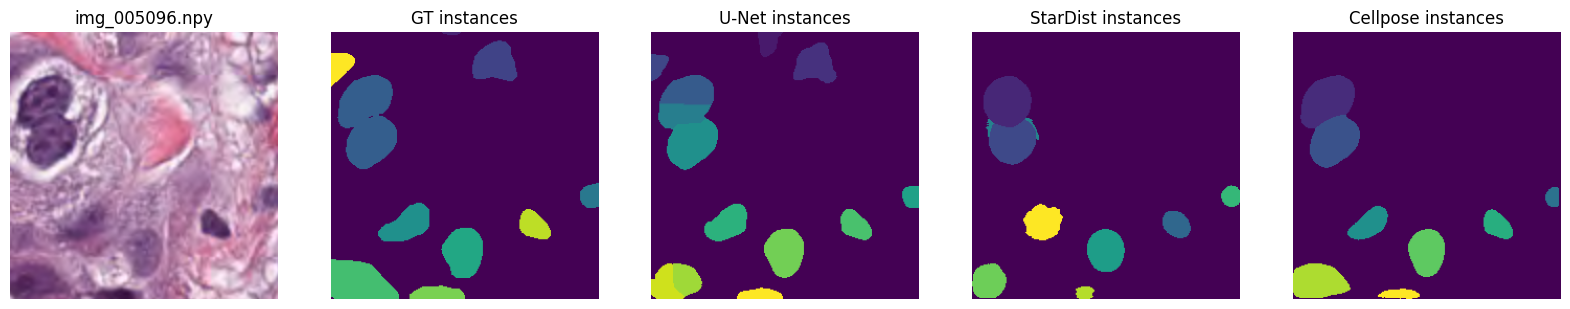

In [60]:
show_case(idx=10, split="test")

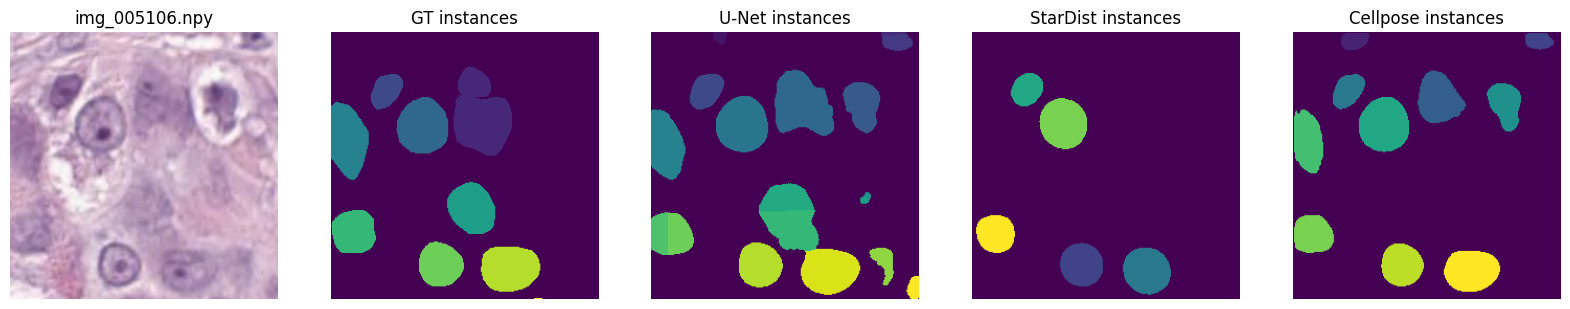

In [61]:
show_case(idx=20, split="test")

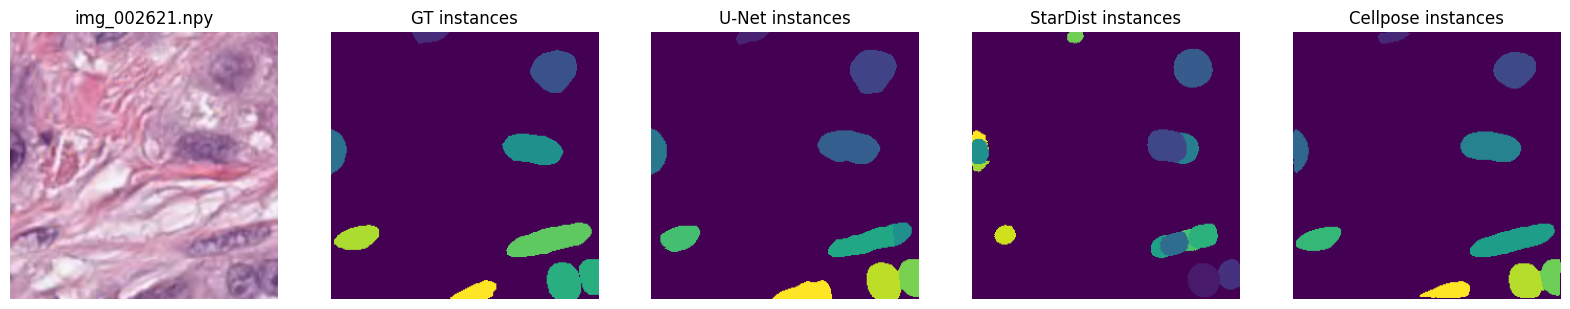

In [62]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from cellpose import models as cp_models

# ------------------------------------------------------------
# Cellpose (v4+): instanciation unique
# ------------------------------------------------------------
_CP = None

def get_cellpose():
    global _CP
    if _CP is None:
        # En v4.0.1+, model_type est ignoré, donc on ne le passe pas.
        _CP = cp_models.CellposeModel(gpu=torch.cuda.is_available())
    return _CP


def show_case(
    idx=0,
    split="val",
    unet_thr=0.5,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=5000,
    vote_thr=0.5,
    use_local_maxima=False,
    local_max_footprint=9,
    cp_diameter=None,
):
    ds = get_raw_dataset(split)
    img_t, gt_inst_t, _, name = ds[idx]

    img = img_t.permute(1, 2, 0).cpu().numpy()  # (H,W,3) float
    gt = gt_inst_t.cpu().numpy().astype(np.int32)

    # ---------- U-Net ----------
    with torch.no_grad():
        prob_unet = torch.sigmoid(unet(img_t.unsqueeze(0).to(DEVICE)))[0, 0].detach().cpu().numpy()
    unet_inst = unet_prob_to_instances(prob_unet, thr=unet_thr)

    # ---------- StarDist ----------
    with torch.no_grad():
        prob_logits, dist_pos, class_logits = sd(img_t.unsqueeze(0).to(DEVICE))

    prob_sd = torch.sigmoid(prob_logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    dist_sd = dist_pos[0].detach().cpu().numpy().astype(np.float32)
    class_prob = torch.softmax(class_logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)

    sd_inst, _sd_cls = stardist_decode(
        prob_map=prob_sd,
        dist_map=dist_sd,
        class_prob=class_prob,
        prob_thr=float(prob_thr),
        nms_iou_thr=float(nms_iou_thr),
        min_area=int(min_area),
        max_candidates=int(max_candidates),
        vote_thr=float(vote_thr),
        use_local_maxima=bool(use_local_maxima),
        local_max_footprint=int(local_max_footprint),
    )

    # ---------- Cellpose (v4+) ----------
    # Cellpose aime bien uint8; si img est [0,1], convertir proprement
    if img.dtype != np.uint8:
        img_cp = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    else:
        img_cp = img

    cp = get_cellpose()

    # En v4.0.1+, eval retourne 3 valeurs (masks, flows, styles)
    cp_inst, flows, styles = cp.eval(
        img_cp,
        diameter=cp_diameter,   # None = baseline "sans tuning"
        do_3D=False
    )
    cp_inst = cp_inst.astype(np.int32)

    # ---------- Plot ----------
    fig, axs = plt.subplots(1, 5, figsize=(20, 4))
    axs[0].imshow(img); axs[0].set_title(name); axs[0].axis("off")
    axs[1].imshow(gt); axs[1].set_title("GT instances"); axs[1].axis("off")
    axs[2].imshow(unet_inst); axs[2].set_title("U-Net instances"); axs[2].axis("off")
    axs[3].imshow(sd_inst); axs[3].set_title("StarDist instances"); axs[3].axis("off")
    axs[4].imshow(cp_inst); axs[4].set_title("Cellpose instances"); axs[4].axis("off")
    plt.show()


show_case(idx=0, split="val")
